In [ ]:
import os
import random
from collections import Counter
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [ ]:
train_path = "../data/Train/"
test_path = "../data/Train/"
val_path = "../data/Val/"

os.listdir(train_path)

['PNEUMONIA', 'NORMAL']

## 1. Cargar y visualizar ejemplos de ambas clases

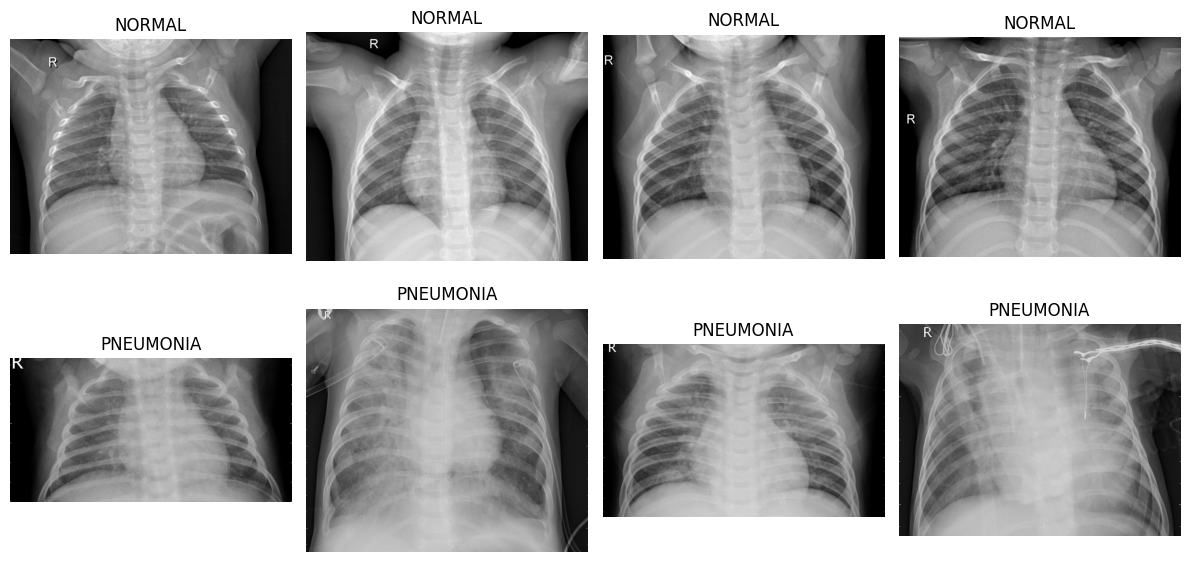

In [ ]:
plt.figure(figsize=(12, 6))
classes = ["NORMAL", "PNEUMONIA"]
for row, cls in enumerate(classes):
    class_dir = os.path.join(train_path, cls)
    images = os.listdir(class_dir)
    sample_imgs = random.sample(images, 4)

    for col, img_name in enumerate(sample_imgs):
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(len(classes), 4, row * 4 + col + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()

## 2.1 Distribución de clases.

In [ ]:
def class_distribution(path):
    classes = os.listdir(path)
    dist = {}
    for cls in classes:
        dist[cls] = len(os.listdir(os.path.join(path, cls)))
    return dist

print("Distribución en TRAIN:")
print(class_distribution(train_path))

print("\nDistribución en TEST:")
print(class_distribution(test_path))

print("\nDistribución en VAL:")
print(class_distribution(val_path))

Distribución en TRAIN:
{'PNEUMONIA': 3875, 'NORMAL': 1341}

Distribución en TEST:
{'PNEUMONIA': 390, 'NORMAL': 234}

Distribución en VAL:
{'PNEUMONIA': 8, 'NORMAL': 8}


La distribución del dataset evidencia un desbalance significativo entre las clases, especialmente en el conjunto de entrenamiento, donde la clase PNEUMONIA triplica el número de imágenes de la clase NORMAL.

Además, el conjunto de validación es extremadamente reducido y no resulta adecuado para evaluar el desempeño durante el entrenamiento, por lo que es necesario reconstruir un split más representativo.

## 2.2 Análisis de los tamaños de las imágenes.

In [ ]:
samples = []
folders = [os.path.join(train_path, "NORMAL"), os.path.join(train_path, "PNEUMONIA")]

for folder in folders:
    imgs = os.listdir(folder)
    chosen = random.sample(imgs, min(150, len(imgs)))
    for img_name in chosen:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            samples.append(img.shape)
sizes = np.array(samples)

heights = sizes[:, 0]
widths = sizes[:, 1]

print("Tamaño (alto x ancho) — análisis:")
print("----------------------------------")
print("Altura mínima:", heights.min())
print("Altura máxima:", heights.max())
print("Altura promedio:", heights.mean())

print("\nAncho mínimo:", widths.min())
print("Ancho máximo:", widths.max())
print("Ancho promedio:", widths.mean())

print(f"\nNúmero de imágenes analizadas: {len(samples)}")

Tamaño (alto x ancho) — análisis:
----------------------------------
Altura mínima: 186
Altura máxima: 2663
Altura promedio: 1124.21

Ancho mínimo: 441
Ancho máximo: 2480
Ancho promedio: 1457.4966666666667

Número de imágenes analizadas: 300


In [ ]:
def analizar_tamanos(path):
    sizes = []
    for cls in os.listdir(path):
        class_dir = os.path.join(path, cls)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                sizes.append(img.shape)  # (alto, ancho)

    counter = Counter(sizes)
    comunes = counter.most_common(5)  # los 5 tamaños más frecuentes

    return comunes, counter


train_sizes, _ = analizar_tamanos(train_path)
test_sizes, _  = analizar_tamanos(test_path)
val_sizes, _   = analizar_tamanos(val_path)

print("Tamaños más comunes en TRAIN:")
for size, freq in train_sizes:
    print(f"  {size}  →  {freq} imágenes")

print("\nTamaños más comunes en TEST:")
for size, freq in test_sizes:
    print(f"  {size}  →  {freq} imágenes")

print("\nTamaños más comunes en VAL:")
for size, freq in val_sizes:
    print(f"  {size}  →  {freq} imágenes")

Tamaños más comunes en TRAIN:
  (648, 1072)  →  7 imágenes
  (728, 1080)  →  6 imágenes
  (704, 1008)  →  5 imágenes
  (680, 1008)  →  5 imágenes
  (672, 976)  →  5 imágenes

Tamaños más comunes en TEST:
  (736, 1112)  →  3 imágenes
  (784, 1120)  →  2 imágenes
  (712, 1096)  →  2 imágenes
  (640, 952)  →  2 imágenes
  (832, 1152)  →  2 imágenes

Tamaños más comunes en VAL:
  (664, 1152)  →  1 imágenes
  (712, 1072)  →  1 imágenes
  (952, 1192)  →  1 imágenes
  (1128, 1664)  →  1 imágenes
  (656, 1016)  →  1 imágenes


El análisis de los tamaños revela que las imágenes del dataset presentan una variabilidad extremadamente alta, con alturas que van desde 186 hasta 2663 píxeles y anchos que oscilan entre 441 y 2480 píxeles. Este comportamiento heterogéneo también se refleja en los promedios relativamente altos (1124×1457), lo que indica que muchas radiografías tienen resoluciones grandes, probablemente producto de diferentes máquinas de rayos X, formatos de exportación y condiciones clínicas. Debido a esta diversidad, no existe un tamaño dominante que permita trabajar directamente sin normalización, y mezclar imágenes tan dispares puede afectar negativamente el proceso de entrenamiento de cualquier modelo, generando distorsiones y pérdidas de información relevante.

Además, los tamaños más comunes encontrados en Train y Test muestran que ningún tamaño se repite con suficiente frecuencia como para considerarse estándar, siendo valores como (648×1072), (728×1080) o (736×1112) apenas marginalmente más frecuentes. En el caso del conjunto de validación, cada imagen tiene un tamaño distinto, lo que refuerza aún más la necesidad de realizar un preprocesamiento consistente. En conjunto, este comportamiento del dataset justifica plenamente la elección de una etapa de resizing obligatoria a un tamaño fijo (por ejemplo 224×224 o 256×256), así como la aplicación de técnicas como CLAHE para uniformar el contraste, permitiendo que el modelo aprenda patrones anatómicos y patológicos y no variaciones ajenas a la patología como la resolución o el rango dinámico original.

## 3. Implementación de pipeline de preprocesamiento.

In [ ]:
drive_base = "../data"

Definimos los parámetros.

In [ ]:
# Tamaño objetivo (puedes cambiar a 224 o 320 según prefieras)
TARGET_SIZE = (256, 256)  # (alto, ancho)

# CLAHE params
CLAHE_CLIP = 2.0
CLAHE_TILE = (8, 8)

# Split ratios
TRAIN_RATIO = 0.75
VAL_RATIO   = 0.15
TEST_RATIO  = 0.10
SEED = 42

In [ ]:
#Recopilamos todas las imagenes para hacer una redistribución de las clases
def gather_image_paths(folders):
    items = []
    for folder in folders:
        for cls in os.listdir(folder):
            cls_dir = os.path.join(folder, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.startswith('.'):
                    continue
                fpath = os.path.join(cls_dir, fname)
                items.append((fpath, cls))
    return items

all_items = gather_image_paths([train_path, test_path, val_path])
print(f"Imágenes encontradas (total): {len(all_items)}")

Imágenes encontradas (total): 5856


In [ ]:
paths = [p for p, c in all_items]
labels = [c for p, c in all_items]

# sanity
assert len(paths) == len(labels)

# Primero separamos train vs temp (train = 70%)
p_train, p_temp, l_train, l_temp = train_test_split(
    paths, labels, train_size=TRAIN_RATIO, stratify=labels, random_state=SEED
)

# luego dividimos temp en val y test con proporciones relativas iguales
# val_fraction = VAL_RATIO / (VAL_RATIO + TEST_RATIO) = 0.5 cuando ambos 15%
rel_val = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
p_val, p_test, l_val, l_test = train_test_split(
    p_temp, l_temp, train_size=rel_val, stratify=l_temp, random_state=SEED
)

print("Split counts:")
print("  train:", len(p_train))
print("  val:  ", len(p_val))
print("  test: ", len(p_test))

Split counts:
  train: 4099
  val:   878
  test:  879


In [ ]:
# ---------- función de preprocesamiento ----------
def preprocess_and_save(src_path, dest_path, target_size=TARGET_SIZE, clahe_clip=CLAHE_CLIP, clahe_tile=CLAHE_TILE):
    """
    Lee la imagen, convierte a grayscale, aplica CLAHE y redimensiona.
    Guarda el resultado en dest_path (jpg).
    """
    # leer en grayscale
    img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
    img_clahe = clahe.apply(img)

    target_w, target_h = target_size[1], target_size[0]
    resized = cv2.resize(img_clahe, (target_w, target_h), interpolation=cv2.INTER_AREA)
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    cv2.imwrite(dest_path, resized, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    return True

In [ ]:
# ---------- preparar carpetas destino y procesar ----------
def process_set(paths_list, labels_list, split_name):
    """
    Guarda en: drive_base/<split_name>/<class>/<original_filename_or_index>.jpg
    """
    for src, label in tqdm(list(zip(paths_list, labels_list)), desc=f"Procesando {split_name}"):
        fname = os.path.basename(src)
        name_wo_ext = os.path.splitext(fname)[0]
        safe = f"{name_wo_ext}_{abs(hash(src)) % (10**8)}.jpg"
        dest_dir = os.path.join(drive_base, split_name, label)
        dest_path = os.path.join(dest_dir, safe)
        ok = preprocess_and_save(src, dest_path)
        if not ok:
            print("Warning: no se pudo leer", src)

In [ ]:

if os.path.exists(drive_base):
    print("La carpeta destino existe. Se recomienda respaldar antes de continuar si hay contenido previo.")
else:
    os.makedirs(drive_base, exist_ok=True)

La carpeta destino existe. Se recomienda respaldar antes de continuar si hay contenido previo.


In [ ]:
# Procesar cada conjunto
process_set(p_train, l_train, "Train")
process_set(p_val,   l_val,   "Val")
process_set(p_test,  l_test,  "Test")

Procesando Test: 100%|██████████| 879/879 [00:35<00:00, 24.76it/s]


In [ ]:
def summarize_folder(base):
    summary = {}
    for split in ["Train", "Val", "Test"]:
        split_dir = os.path.join(base, split)
        if not os.path.isdir(split_dir):
            summary[split] = {}
            continue
        counts = {}
        for cls in os.listdir(split_dir):
            cls_dir = os.path.join(split_dir, cls)
            if os.path.isdir(cls_dir):
                counts[cls] = len([f for f in os.listdir(cls_dir) if not f.startswith('.')])
        summary[split] = counts
    return summary

In [ ]:
summary = summarize_folder(drive_base)
print("\nDistribución final en Drive (preprocesadas):")
for split, d in summary.items():
    print(f" {split}: {d}")



Distribución final en Drive (preprocesadas):
 Train: {'PNEUMONIA': 2991, 'NORMAL': 1108}
 Val: {'NORMAL': 237, 'PNEUMONIA': 641}
 Test: {'PNEUMONIA': 641, 'NORMAL': 238}


In [ ]:
# ---------- calcular class_weights (útil para entrenamiento) ----------
total_train = sum(summary["Train"].values())
class_weights = {}
for i, (cls, cnt) in enumerate(summary["Train"].items()):
    # weight = total / (n_classes * cnt)  -> sklearn compatible mapping por etiqueta index si usas integer labels
    class_weights[cls] = total_train / (len(summary["Train"]) * cnt)
print("\nClass weights (por clase name):")
print(class_weights)

# fin
print("\nPipeline completado. Imágenes preprocesadas guardadas en:")
print(drive_base)


Class weights (por clase name):
{'PNEUMONIA': 0.6852223336676697, 'NORMAL': 1.8497292418772564}

Pipeline completado. Imágenes preprocesadas guardadas en:
/content/drive/Shareddrives/Visión por Computador - Deep Thinking/Trabajo 3/Dataset
